In [2]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (
    dmatrix, bs
)

# Moving Beyond Linearity: An Analysis of the Wage Dataset

In this notebook, we explore non-linear modeling techniques using the `Wage` dataset. Standard linear regression assumes a constant rate of change, which is often an oversimplification of complex real-world phenomena. Human wages, for instance, rarely increase linearly throughout a lifetime. 

We will systematically relax the linearity assumption by progressing through polynomial regression, step functions, regression splines, and natural splines. Our primary objective is to model `wage` as a function of `age`, balancing model flexibility with interpretability and variance control.

In [11]:
# Load the dataset
wage_df = pd.read_csv('Wage.csv')

# 1. Check data types and missing values
display(wage_df.info())

# 2. Preview the first few rows
display(wage_df.head())

# Set up global plotting parameters for academic clarity
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   maritl      3000 non-null   object 
 3   race        3000 non-null   object 
 4   education   3000 non-null   object 
 5   region      3000 non-null   object 
 6   jobclass    3000 non-null   object 
 7   health      3000 non-null   object 
 8   health_ins  3000 non-null   object 
 9   logwage     3000 non-null   float64
 10  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 257.9+ KB


None

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


## Exploratory Data Analysis

Before imposing a mathematical structure on our data, empirical observation is required. We visualize the bivariate relationship between `age` and `wage`. 

Notice the discernible non-linear "hump" in the scatter plot. Wages experience rapid growth in early career stages, plateau during middle age, and exhibit a slight decline or increased variance as workers approach retirement. Fitting a simple linear model $y_i = \beta_0 + \beta_1 x_i + \epsilon_i$ would systematically under-predict wages for middle-aged workers and over-predict for the youngest and oldest workers.

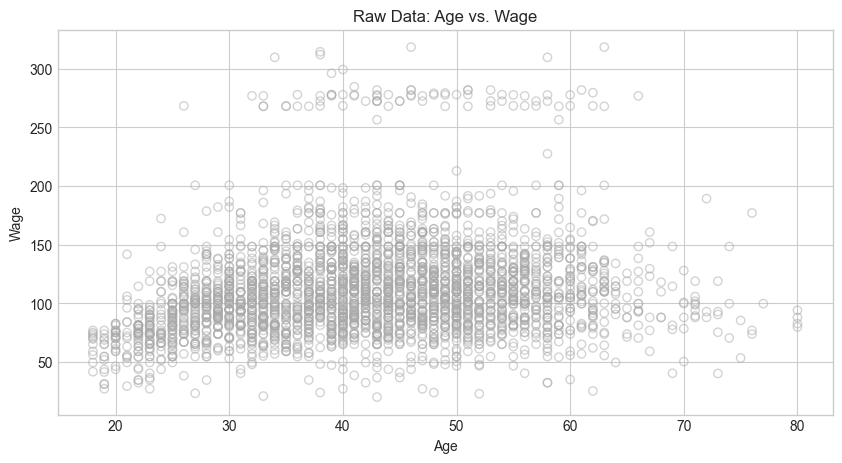

In [12]:
# Create a base scatter plot to use throughout the notebook
def plot_wage_data():
    fig, ax = plt.subplots()
    ax.scatter(wage_df['age'], wage_df['wage'], facecolors='none', edgecolors='darkgray', alpha=0.5)
    ax.set_xlabel('Age')
    ax.set_ylabel('Wage')
    return fig, ax

fig, ax = plot_wage_data()
ax.set_title('Raw Data: Age vs. Wage')
plt.show()

## Polynomial Regression

Our first approach to capturing non-linearity is to extend the linear model by incorporating engineered features. We raise our predictor, `age`, to successive powers, creating a polynomial of degree $d$. For a degree-4 polynomial, the model is:

$$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + \beta_4 x_i^4 + \epsilon_i$$

While this is a non-linear curve in the two-dimensional space of age and wage, it remains a *linear* model in terms of its coefficients ($\beta$). Thus, it can be estimated using standard Ordinary Least Squares (OLS). A fundamental limitation of this approach is its global nature; the shape of the curve at age 60 is heavily influenced by the data points at age 20.

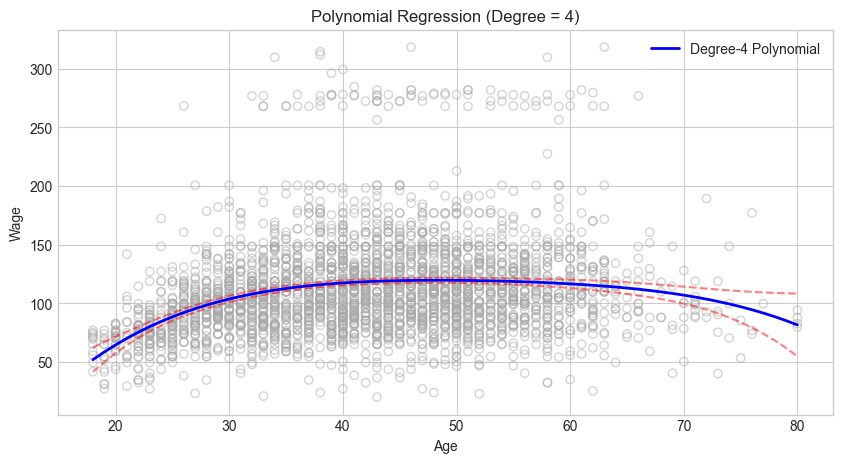

In [68]:
# Fit a degree-4 polynomial
fit_poly = smf.ols('wage ~ age + np.power(age, 2) + np.power(age, 3) + np.power(age, 4)', data=wage_df).fit()

# Generate a grid of age values for smooth plotting
age_grid = np.arange(wage_df['age'].min(), wage_df['age'].max() + 1)
pred_poly = fit_poly.get_prediction(pd.DataFrame({'age': age_grid}))

# Extract predictions and standard error bands
poly_mean = pred_poly.predicted_mean
poly_ci = pred_poly.conf_int()

fig, ax = plot_wage_data()
ax.plot(age_grid, poly_mean, color='blue', linewidth=2, label='Degree-4 Polynomial')
ax.plot(age_grid, poly_ci[:, 0], color='red', linestyle='dashed', alpha=0.5)
ax.plot(age_grid, poly_ci[:, 1], color='red', linestyle='dashed', alpha=0.5)
ax.set_title('Polynomial Regression (Degree = 4)')
ax.legend()
plt.show()

## Step Functions

To avoid the global constraints of polynomials, we can adopt a localized approach using step functions. We partition the domain of $X$ into $K$ distinct, non-overlapping regions and fit a constant value (the mean) within each region. 

We construct indicator variables $C_k(X)$ that evaluate to 1 if $X$ falls within the $k$-th interval, and 0 otherwise. The model is formulated as:

$$y_i = \beta_0 + \beta_1 C_1(x_i) + \beta_2 C_2(x_i) + \dots + \beta_K C_K(x_i) + \epsilon_i$$

This isolates local behavior, but introduces a severe structural flaw: discontinuity. The model predicts arbitrary, sudden jumps in wage precisely at the interval boundaries, which violates the underlying reality of human earning trajectories.

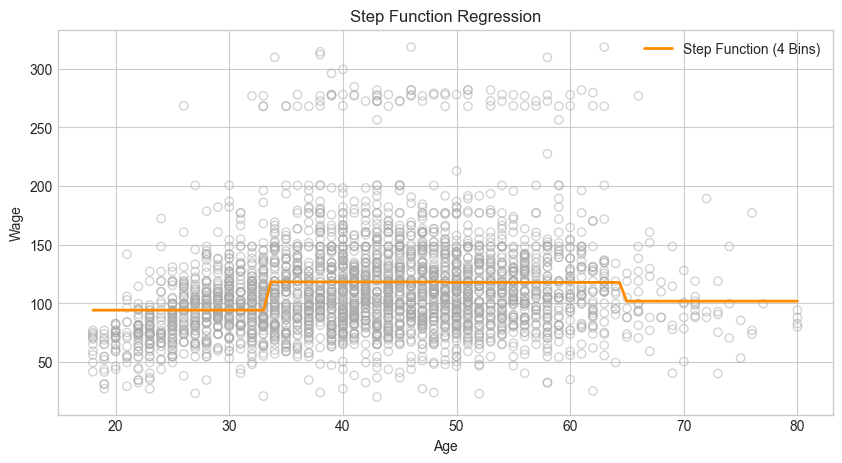

In [29]:
# Cut age into 4 bins
wage_df['age_bins'] = pd.cut(wage_df['age'], 4)

# Fit OLS on the dummy variables generated by the bins
fit_step = smf.ols('wage ~ age_bins', data=wage_df).fit()

# Predict using the grid
step_grid_df = pd.DataFrame({'age': age_grid})
step_grid_df['age_bins'] = pd.cut(step_grid_df['age'], bins=wage_df['age_bins'].cat.categories)
pred_step = fit_step.predict(step_grid_df)

fig, ax = plot_wage_data()
ax.plot(age_grid, pred_step, color='darkorange', linewidth=2, label='Step Function (4 Bins)')
ax.set_title('Step Function Regression')
ax.legend()
plt.show()

## Regression Splines

Regression splines synthesize the flexibility of step functions with the smoothness of polynomials. We divide the data into regions separated by breakpoints called **knots**. Instead of fitting a constant in each region, we fit a low-degree polynomial (typically a cubic polynomial, $d=3$).

To prevent the disjointed jumps seen in step functions, we impose mathematical constraints: the piecewise polynomials must be continuous at the knots, and their first and second derivatives must also be continuous. This results in a curve that is highly flexible but visually seamless.

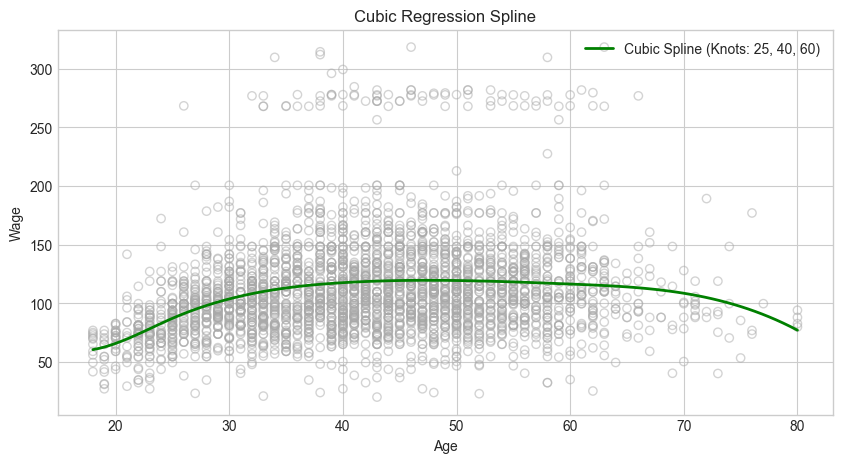

In [30]:
# Create a cubic spline basis with knots at ages 25, 40, and 60
# 'bs' generates a B-spline basis
spline_basis = dmatrix("bs(age, knots=(25, 40, 60), degree=3, include_intercept=False)", {"age": wage_df['age']}, return_type='dataframe')

# Fit the model
fit_spline = sm.GLS(wage_df['wage'], sm.add_constant(spline_basis)).fit()

# Predict on the grid
spline_grid_basis = dmatrix("bs(age, knots=(25, 40, 60), degree=3, include_intercept=False)", {"age": age_grid}, return_type='dataframe')
pred_spline = fit_spline.predict(sm.add_constant(spline_grid_basis))

fig, ax = plot_wage_data()
ax.plot(age_grid, pred_spline, color='green', linewidth=2, label='Cubic Spline (Knots: 25, 40, 60)')
ax.set_title('Cubic Regression Spline')
ax.legend()
plt.show()

## Natural Splines

A known vulnerability of standard regression splines is their erratic behavior at the boundaries of the dataset (where $X$ takes its smallest and largest values), leading to wide confidence intervals. 

**Natural splines** solve this by adding an extra boundary constraint: the function is forced to be linear beyond the outermost knots. This regularization step significantly reduces variance in the tails of the distribution, providing a more stable and reliable model for extreme age values.

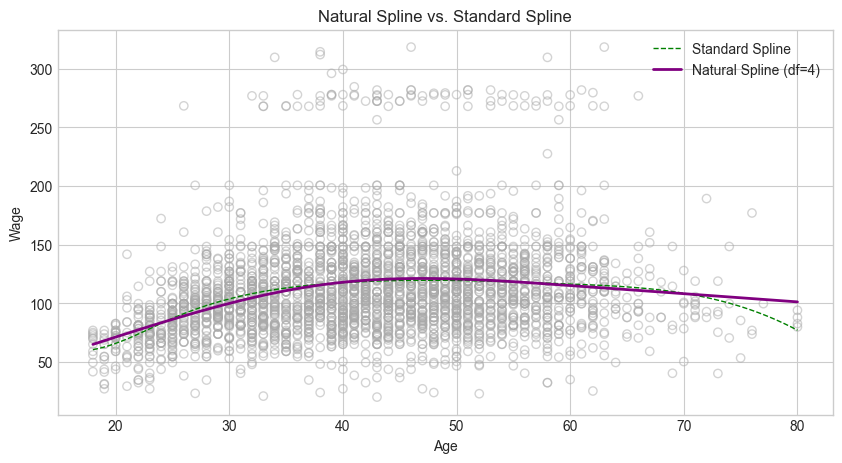

In [31]:
# Create a natural cubic spline basis ('cr' in patsy) with 4 degrees of freedom
nat_spline_basis = dmatrix("cr(age, df=4)", {"age": wage_df['age']}, return_type='dataframe')

# Fit the model
fit_nat_spline = sm.GLS(wage_df['wage'], sm.add_constant(nat_spline_basis)).fit()

# Predict on the grid
nat_spline_grid = dmatrix("cr(age, df=4)", {"age": age_grid}, return_type='dataframe')
pred_nat_spline = fit_nat_spline.predict(sm.add_constant(nat_spline_grid))

fig, ax = plot_wage_data()
ax.plot(age_grid, pred_spline, color='green', linewidth=1, linestyle='dashed', label='Standard Spline')
ax.plot(age_grid, pred_nat_spline, color='purple', linewidth=2, label='Natural Spline (df=4)')
ax.set_title('Natural Spline vs. Standard Spline')
ax.legend()
plt.show()

## Statistical Justification via ANOVA

Visual inspection is insufficient for rigorous model selection. We must statistically justify the **Global Polynomial Degree** (our chosen degree of flexibility or power of X and not the degree of freedom). We will sequentially fit polynomial models of increasing degrees (from linear to quintic) and use an Analysis of Variance (ANOVA) to conduct an F-test.

The null hypothesis ($H_0$) for each sequential test is that the simpler model is sufficient to explain the data. A low p-value indicates that the more complex model provides a statistically significant improvement in reducing the residual sum of squares (RSS).

In [38]:
# Fit sequential polynomial models
fit_1 = smf.ols('wage ~ age', data=wage_df).fit()
fit_2 = smf.ols('wage ~ age + np.power(age, 2)', data=wage_df).fit()
fit_3 = smf.ols('wage ~ age + np.power(age, 2) + np.power(age, 3)', data=wage_df).fit()
fit_4 = smf.ols('wage ~ age + np.power(age, 2) + np.power(age, 3) + np.power(age, 4)', data=wage_df).fit()
fit_5 = smf.ols('wage ~ age + np.power(age, 2) + np.power(age, 3) + np.power(age, 4) + np.power(age, 5)', data=wage_df).fit()

# Run ANOVA F-tests to compare nested models
anova_results = sm.stats.anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5, typ=1)

# --- NEW CODE TO SUPPRESS SCIENTIFIC NOTATION ---
# Temporarily change pandas display options to use standard float formatting
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(anova_results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0000,5022216.1047,0.0000,NaN,NaN,NaN
1,2997.0000,4793430.0946,1.0000,228786.0101,143.5931,0.0000
2,2996.0000,4777674.4010,1.0000,15755.6937,9.8888,0.0017
3,2995.0000,4771604.2488,1.0000,6070.1521,3.8098,0.0510
4,2994.0000,4770321.6858,1.0000,1282.5630,0.8050,0.3697


### Interpretation of ANOVA Results

The Analysis of Variance (ANOVA) table above provides a formal statistical mechanism for model selection. Because we fitted a sequence of nested models—where each subsequent model simply adds one higher-degree polynomial term—we can use an F-test to determine if the additional complexity is justified. 

The null hypothesis ($H_0$) for each step is that the simpler model is sufficient, meaning the coefficient for the newly added higher-degree term is effectively zero.

Here is the sequential breakdown of the results:

* **Linear vs. Quadratic (Degree 1 to 2):** The transition to a quadratic model yields an F-statistic of $143.59$ and a p-value of approximately $0.0000$. We emphatically reject the null hypothesis. This confirms our initial visual EDA: the relationship between age and wage is undeniably non-linear.
* **Quadratic vs. Cubic (Degree 2 to 3):** Adding a cubic term reduces the Residual Sum of Squares (RSS) further, with a p-value of $0.0017$. Since $0.0017 < 0.05$, this suggests the cubic term captures important structural curvature in the data that the quadratic model misses.
* **Cubic vs. Quartic (Degree 3 to 4):** The addition of a degree-4 term yields a p-value of $0.0510$. This is right on the boundary of the standard $5\%$ significance threshold ($\alpha = 0.05$). In practice, one might argue for either the cubic or quartic model here, but the evidence for needing a degree-4 polynomial is comparatively weak.
* **Quartic vs. Quintic (Degree 4 to 5):** Adding a degree-5 term yields a p-value of $0.3697$. This is not statistically significant. The quintic term does not meaningfully reduce the RSS; it merely fits to the random noise (variance) of our specific sample.

**Conclusion:**
The statistical evidence strongly supports abandoning the linear model in favor of a non-linear one. A cubic polynomial (Degree 3) is clearly justified by the data. While a quartic polynomial (Degree 4) provides a marginal improvement, anything beyond degree 4 introduces unnecessary complexity without predictive benefit, leading to overfitting.

## Hyperparameter Tuning: K-Fold Cross-Validation vs. ANOVA

Optimal Degrees of Freedom: 5


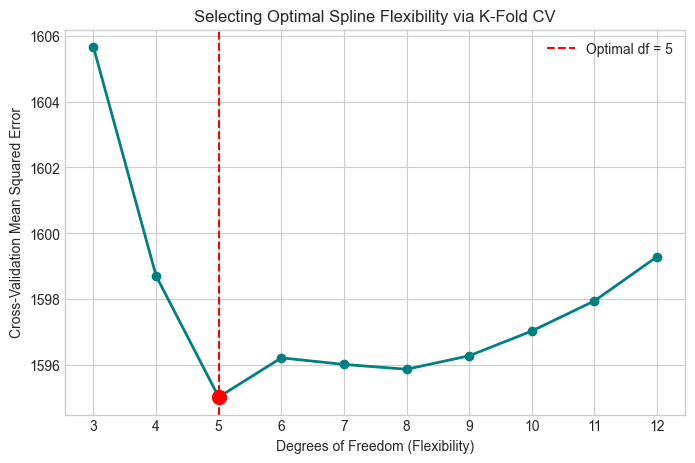

In [70]:
# -----------------------------
# 1. Setup Cross-Validation
# -----------------------------
# We will test degrees of freedom from 3 to 12
# (Note: Natural splines require a minimum of df=3)
df_range = range(3, 13)
cv_errors = []

# Initialize K-Fold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 2. The CV Loop
# -----------------------------
for d in df_range:
    fold_errors = []
    
    for train_index, test_index in kf.split(wage_df):
        # Split the data into Training (80%) and Testing (20%)
        train_data = wage_df.iloc[train_index]
        test_data = wage_df.iloc[test_index]
        
        # Fit the Natural Spline on the TRAINING data
        model = smf.ols(f"wage ~ cr(age, df={d})", data=train_data).fit()
        
        # Predict on the unseen TEST data
        preds = model.predict(test_data)
        
        # Calculate Mean Squared Error for this fold
        mse = mean_squared_error(test_data["wage"], preds)
        fold_errors.append(mse)
        
    # Average the MSE across all 5 folds for this specific df
    cv_errors.append(np.mean(fold_errors))

# -----------------------------
# 3. Identify the Optimal df
# -----------------------------
best_idx = np.argmin(cv_errors)
best_df = df_range[best_idx]
min_error = cv_errors[best_idx]

print(f"Optimal Degrees of Freedom: {best_df}")

# -----------------------------
# 4. Plot the CV Curve
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(df_range, cv_errors, marker='o', linestyle='-', color='teal', lw=2)
plt.axvline(best_df, color='red', linestyle='--', label=f'Optimal df = {best_df}')
plt.scatter(best_df, min_error, color='red', s=100, zorder=5)

plt.xlabel("Degrees of Freedom (Flexibility)")
plt.ylabel("Cross-Validation Mean Squared Error")
plt.title("Selecting Optimal Spline Flexibility via K-Fold CV")
plt.xticks(df_range)
plt.legend()

plt.show()

In our previous section, we used an **ANOVA F-test** to determine the optimal complexity of a global polynomial. That approach relied on classical in-sample hypothesis testing. However, to optimize our local models (Natural Splines), we transition to a modern machine learning approach: **K-Fold Cross-Validation**.

Instead of relying on p-values, Cross-Validation empirically tests how well the model generalizes to unseen data. 

**The Process:**
We split our dataset into 5 equal folds. For each degree of freedom ($df$) between 3 and 12, we train the natural spline on 4 folds and test its predictions on the 1 holdout fold. We rotate this process 5 times and average the out-of-sample Mean Squared Error (MSE).

**The Bias-Variance Tradeoff:**
The resulting plot visualizes the classic bias-variance tradeoff:
* **Underfitting (Left side):** At low $df$, the model is too rigid to capture the true non-linear wage lifecycle, resulting in higher errors.
* **Overfitting (Right side):** Beyond the optimal $df$, adding more knots allows the spline to memorize statistical noise in the training folds, which harms its accuracy on the test folds.

By selecting the $df$ that strictly minimizes the Cross-Validation MSE, we allow the data to objectively define its own optimal mathematical flexibility.

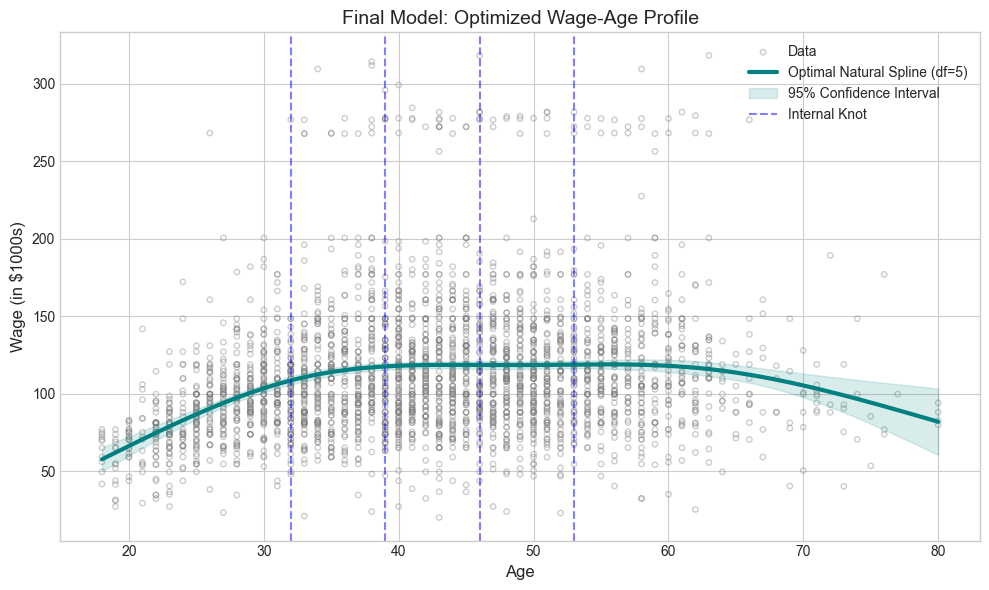

Knots placed at ages: [32. 39. 46. 53.]


In [74]:
# -----------------------------
# 1. Fit the "Champion" Model
# -----------------------------
# We use df=5 as proven by our Cross-Validation
optimal_model = smf.ols("wage ~ cr(age, df=5)", data=wage_df).fit()

# Generate predictions and confidence intervals
pred_data = optimal_model.get_prediction(age_df).summary_frame()

# -----------------------------
# 2. Identify Knot Locations
# -----------------------------
# For df=5, knots are typically at these percentiles
knot_locations = np.percentile(wage_df['age'], [20, 40, 60, 80])

# -----------------------------
# 3. Plotting the Results
# -----------------------------
plt.figure(figsize=(10, 6))

# Raw Data
plt.scatter(wage_df['age'], wage_df['wage'], facecolors='none', 
            edgecolors='grey', alpha=0.4, s=15, label='Data')

# The Optimal Spline
plt.plot(age_grid, pred_data['mean'], color='teal', lw=3, 
         label=f'Optimal Natural Spline (df=5)')

# Confidence Intervals
plt.fill_between(age_grid, pred_data['mean_ci_lower'], pred_data['mean_ci_upper'], 
                 color='teal', alpha=0.15, label='95% Confidence Interval')

# Visualizing the Knots
for i, knot in enumerate(knot_locations):
    plt.axvline(knot, color='blue', linestyle='--', alpha=0.5, 
                label='Internal Knot' if i == 0 else "")

plt.title("Final Model: Optimized Wage-Age Profile", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Wage (in $1000s)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Knots placed at ages: {np.round(knot_locations, 1)}")

## Interpreting the "Winning" Model ($df=5$)

Our Cross-Validation process identified a **Natural Cubic Spline with 5 Degrees of Freedom** as the optimal model. But what does that "5" actually represent in practice? 

Think of **Degrees of Freedom ($df$)** as a "Complexity Budget" that the model spends to capture the shape of the data.

### 1. The Number of "Hinges" (Knots)
For a Natural Cubic Spline, the relationship between flexibility and internal knots is defined as:
$$\text{Internal Knots} = df - 1$$

With **$df=5$**, the model has placed **4 internal knots**. These knots act like structural hinges, dividing the age range into segments. Inside each segment, the model fits a cubic polynomial ($X^3$). At the knots, these polynomials are joined so perfectly that the human eye cannot see the "seams," resulting in a single, smooth curve.



### 2. The "Natural" Constraint
While a standard spline can become erratic at the edges of the data, a **Natural** spline (indicated by the `cr` or "Cubic Regression" basis) adds a specific constraint: the function must be **linear** (a straight line) beyond the outermost knots.
* This constraint "saves" degrees of freedom, allowing the model to focus its flexibility on the middle of the age range where the data is most dense.
* This is why our $df=5$ model remains stable at age 18 and age 80, rather than "wagging" wildly like a high-degree polynomial.

### 3. Finding the "Sweet Spot"
The $df=5$ result represents the ideal balance in the **Bias-Variance Tradeoff**:
* **Too Low ($df < 3$):** The model is too rigid (underfit) and might miss the peak earning years entirely.
* **Too High ($df > 8$):** The model becomes too "wiggly" (overfit), chasing random outliers and individual high-earners rather than the general population trend.
* **Optimal ($df = 5$):** The model is flexible enough to capture the rapid wage growth of the 20s, the plateau of the 40s, and the gradual decline toward retirement, without being distracted by statistical noise.

# Annex 1. 
## ISLP textbook graphs
### Polynomial Modeling: Continuous and Binary Outcomes

In [66]:
# Load the dataset
Wage = pd.read_csv('Wage.csv')

# 1. Transform age into degree-4 features
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(Wage[['age']])

### --- Regression --- ###
# 2. Left Plot: Linear Regression
model_linear = sm.OLS(Wage['wage'], X_poly).fit()
# Use model_linear.get_prediction().summary_frame() for CI bands

### --- Classification --- ###
# 3. Right Plot: Logistic Regression
y_binary = (Wage['wage'] > 250).astype(int)
model_logit = sm.Logit(y_binary, X_poly).fit()
# Predict and plot using the logistic sigmoid function: 1 / (1 + exp(-Xb))

Optimization terminated successfully.
         Current function value: 0.116870
         Iterations 12


In this section, we apply degree-4 polynomial transformations to model the relationship between a worker's age and their wage. By utilizing Polynomial Features, we expand our single predictor $X$ (age) into a feature matrix containing $X^0, X^1, X^2, X^3,$ and $X^4$.
We explore this non-linear relationship through two distinct statistical lenses:

1. **Continuous Outcome (Polynomial Regression)**

First, we treat wage as a continuous variable. We fit a standard Ordinary Least Squares (OLS) model using our expanded polynomial feature matrix. The model takes the form:

$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + \beta_4 x_i^4 + \epsilon_i$

This allows us to estimate the expected wage for any given age, capturing the curvature of the earning lifecycle (the rapid increase in early career, the plateau in middle age, and the slight decline approaching retirement).

2. **Binary Outcome (Logistic Regression)** 

Next, we shift from regression to classification to investigate the probability of a worker being a "high earner." We construct a binary response variable, $y_i$, which equals $1$ if a worker earns more than $250,000$, and $0$ otherwise.
We model this binary outcome using Logistic Regression applied to our same degree-4 polynomial features. Instead of predicting the raw wage, we model the log-odds of being a high earner. The probability $\Pr(y_i > 250 | x_i)$ is expressed via the logistic function:

$\Pr(y_i > 250 | x_i) = \frac{\exp(\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + \beta_4 x_i^4)}{1 + \exp(\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + \beta_4 x_i^4)}$

This dual approach illustrates the versatility of basis expansions: transforming our predictors via polynomials is completely agnostic to the type of model we subsequently fit, whether it is standard linear regression or logistic classification.

### Implementation: Visualizing Polynomial Models

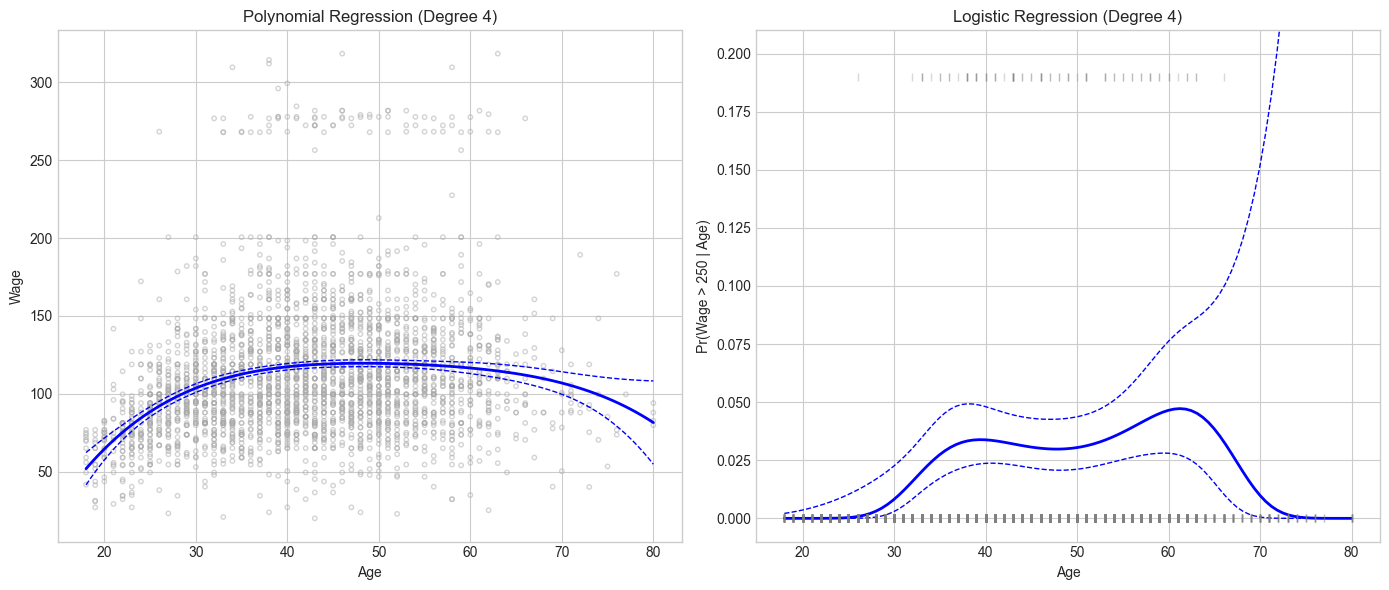

In [43]:
# -----------------------------
# 1. Setup
# -----------------------------
age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 100)

# Polynomial features (shared for both models) [scikit-learn approach]
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(Wage[['age']])
X_grid_poly = poly.transform(age_grid.reshape(-1, 1))

# -----------------------------
# 2. Linear Regression
# -----------------------------
model_linear = sm.OLS(Wage['wage'], X_poly).fit()
# Get predictions and confidence intervals using the grid matrix
pred_linear = model_linear.get_prediction(X_grid_poly).summary_frame()

# -----------------------------
# 3. Logistic Regression
# -----------------------------
y_binary = (Wage['wage'] > 250).astype(int)
model_logit = sm.Logit(y_binary, X_poly).fit(disp=0)
# Linear predictor
logit_mean = model_logit.predict(X_grid_poly, linear=True)

# Variance calculation
cov_beta = model_logit.cov_params()
logit_var = np.sum(X_grid_poly @ cov_beta * X_grid_poly, axis=1)
logit_se = np.sqrt(logit_var)

# Confidence intervals (logit scale → probability scale)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

p_mean = sigmoid(logit_mean)
p_lower = sigmoid(logit_mean - 2 * logit_se)
p_upper = sigmoid(logit_mean + 2 * logit_se)

# -----------------------------
# 4. Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Linear Regression ---
axes[0].scatter(Wage.age, Wage.wage, facecolors='none',
                edgecolors='darkgrey', s=10, alpha=0.5)

axes[0].plot(age_grid, pred_linear['mean'], color='blue', lw=2)
axes[0].plot(age_grid, pred_linear['mean_ci_lower'], '--', color='blue', lw=1)
axes[0].plot(age_grid, pred_linear['mean_ci_upper'], '--', color='blue', lw=1)

axes[0].set_xlabel('Age')
axes[0].set_ylabel('Wage')
axes[0].set_title('Polynomial Regression (Degree 4)')


# --- Right: Logistic Regression ---
axes[1].plot(age_grid, p_mean, color='blue', lw=2)
axes[1].plot(age_grid, p_lower, '--', color='blue', lw=1)
axes[1].plot(age_grid, p_upper, '--', color='blue', lw=1)

# Rug plot
axes[1].plot(Wage['age'], y_binary * 0.19, '|', color='grey', alpha=0.3)
axes[1].plot(Wage['age'], np.zeros(len(Wage)), '|', color='grey', alpha=0.3)

axes[1].set_ylim(-0.01, 0.21)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Pr(Wage > 250 | Age)')
axes[1].set_title('Logistic Regression (Degree 4)')

plt.tight_layout()
plt.show()

This code bridges theory and practice by reproducing the core polynomial graphics from the ISLP text. We construct a shared degree-4 polynomial feature matrix to evaluate both a continuous and a binary response over a uniform grid of `age` values.

**1. Left Panel: Continuous Wage Prediction**
Using Ordinary Least Squares (OLS), we regress `wage` onto our polynomial basis. The `get_prediction()` method efficiently computes the expected mean wage and 95% confidence intervals at each age, allowing us to overlay the resulting non-linear curve and its error bands directly onto the empirical scatter plot.

**2. Right Panel: High-Earner Probability Calculation**
To model the probability of being a high earner (>$250\text{k}$), we apply Logistic Regression. Crucially, to ensure our confidence bands remain mathematically valid (strictly bounded between 0 and 1), we compute the variance and confidence bounds on the unbounded linear logit scale ($X\hat{\beta} \pm 2 \cdot \text{SE}$). We then map these bounds back to the probability scale via the inverse logit (sigmoid) function. A marginal rug plot is added to visualize the sparse, binary distribution of the actual high-earner data.

### A Unified View of Non-Linear Modeling

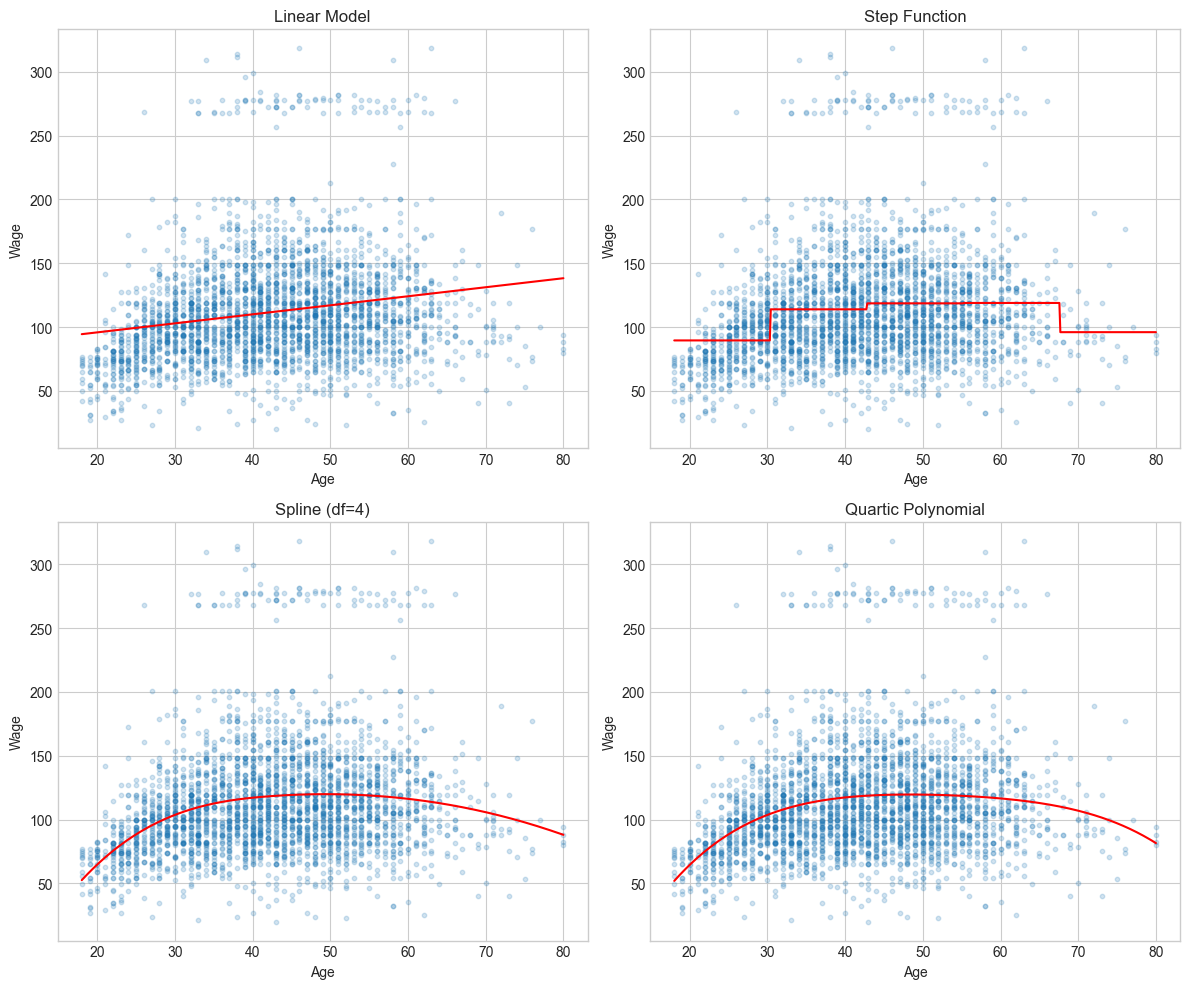

In [83]:
age_grid = np.linspace(Wage["age"].min(), Wage["age"].max(), 500)
age_df = pd.DataFrame({"age": age_grid})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -------------------
# 1. Linear
# -------------------
linear = smf.ols("wage ~ age", data=Wage).fit()
pred_linear = linear.predict(age_df)

axes[0, 0].scatter(Wage["age"], Wage["wage"], alpha=0.2, s=10)
axes[0, 0].plot(age_grid, pred_linear, color="red")
axes[0, 0].set_title("Linear Model")

# -------------------
# 2. Step function
# -------------------
Wage["age_bin"] = pd.cut(Wage["age"], bins=5)
step = smf.ols("wage ~ age_bin", data=Wage).fit()

age_df_step = age_df.copy()
age_df_step["age_bin"] = pd.cut(age_df_step["age"], bins=5)

pred_step = step.predict(age_df_step)

axes[0, 1].scatter(Wage["age"], Wage["wage"], alpha=0.2, s=10)
axes[0, 1].plot(age_grid, pred_step, color="red")
axes[0, 1].set_title("Step Function")

# -------------------
# 3. Spline
# -------------------
spline = smf.ols("wage ~ bs(age, df=4)", data=Wage).fit()
pred_spline = spline.predict(age_df)

axes[1, 0].scatter(Wage["age"], Wage["wage"], alpha=0.2, s=10)
axes[1, 0].plot(age_grid, pred_spline, color="red")
axes[1, 0].set_title("Spline (df=4)")

# -------------------
# 4. QUARTIC - not quadratic
# -------------------
poly4 = smf.ols(
    "wage ~ age + I(age**2) + I(age**3) + I(age**4)",
    data=Wage
).fit()

pred_poly4 = poly4.predict(age_df)

axes[1, 1].scatter(Wage["age"], Wage["wage"], alpha=0.2, s=10)
axes[1, 1].plot(age_grid, pred_poly4, color="red")
axes[1, 1].set_title("Quartic Polynomial")

# -------------------
# Layout polish
# -------------------
for ax in axes.ravel():
    ax.set_xlabel("Age")
    ax.set_ylabel("Wage")

plt.tight_layout()
plt.show()

To conclude our exploration of basis expansions, we visualize four distinct modeling approaches side-by-side. This grid highlights the structural assumptions and geometric properties inherent to each method when mapping the relationship between `age` and `wage`.

**1. The Linear Model (Top Left)**
The standard OLS regression forces a rigid, constant rate of change across the entire age domain. It systematically fails to capture the macroeconomic reality of the earning lifecycle, drastically under-predicting the wages of middle-aged workers.

**2. The Step Function (Top Right)**
By slicing the age variable into 5 distinct intervals, the step function applies a local constant (the mean wage) to each bin. While it successfully identifies the general "hump" shape of the data, the model is characterized by unnatural, discontinuous jumps at arbitrary age boundaries.

**3. The Cubic Spline (Bottom Left)**
Using a B-spline with 6 degrees of freedom ($df=6$), this model divides the data at internal knots and fits localized cubic polynomials. The mathematical constraints ensure continuous first and second derivatives at the boundaries, resulting in a highly flexible, beautifully smooth curve that tracks the data's density elegantly.

**4. The Quartic Polynomial (Bottom Right)**
The degree-4 polynomial provides a globally smooth curve. In this specific dataset, the quartic model and the cubic spline yield visually similar predictions in the interior of the data. However, the polynomial remains a global function, meaning its shape is rigidly tied to the data at the extremes, lacking the localized adaptability that makes splines the preferred tool in modern statistical learning.

### Model Flexibility and Overfitting: Polynomials vs. Splines

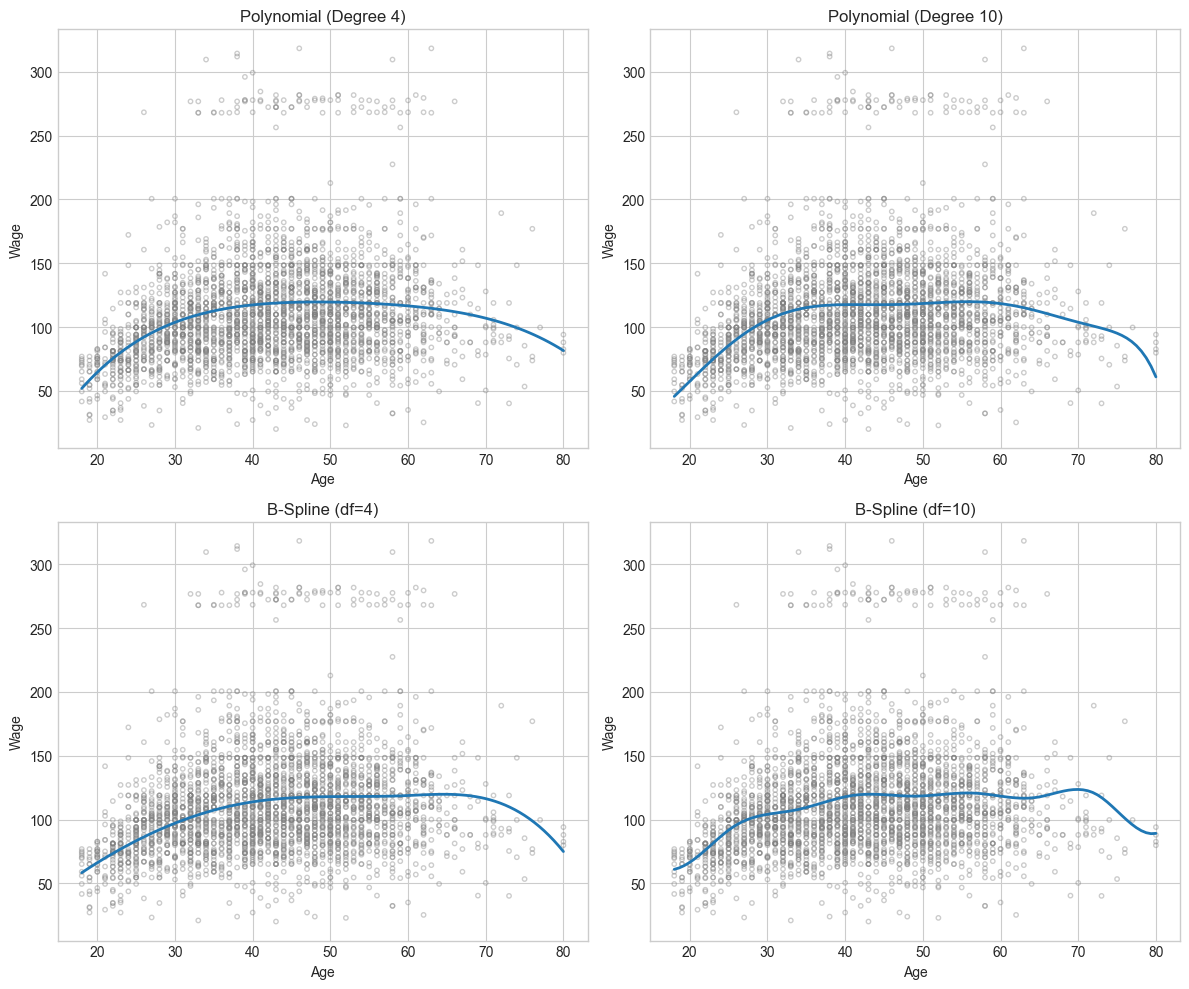

In [86]:
# Grid
age_grid = np.linspace(Wage.age.min(), Wage.age.max(), 100)
age_df = pd.DataFrame({'age': age_grid})

# -----------------------------
# MODELS
# -----------------------------

# Polynomial degree 4
poly4 = ols("wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=Wage).fit()
pred_poly4 = poly4.predict(age_df)

# Polynomial degree 10
poly10 = ols(
    "wage ~ " + " + ".join([f"I(age**{i})" for i in range(1, 11)]),
    data=Wage
).fit()
pred_poly10 = poly10.predict(age_df)

# Spline df=4
spline4_basis = dmatrix("bs(age, df=4, degree=3)", data=Wage)
spline4 = sm.OLS(Wage['wage'], spline4_basis).fit()
spline4_grid = dmatrix("bs(age, df=4, degree=3)", data=age_df)
pred_spline5 = spline4.predict(spline4_grid)

# Spline df=10
spline10_basis = dmatrix("bs(age, df=10, degree=3)", data=Wage)
spline10 = sm.OLS(Wage['wage'], spline10_basis).fit()
spline10_grid = dmatrix("bs(age, df=10, degree=3)", data=age_df)
pred_spline10 = spline10.predict(spline10_grid)

# -----------------------------
# PLOTS
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

def plot_panel(ax, pred, title):
    ax.scatter(Wage.age, Wage.wage,
               facecolors='none', edgecolors='grey',
               alpha=0.4, s=10)
    ax.plot(age_grid, pred, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Age")
    ax.set_ylabel("Wage")

plot_panel(axs[0, 0], pred_poly4, "Polynomial (Degree 4)")
plot_panel(axs[0, 1], pred_poly10, "Polynomial (Degree 10)")
plot_panel(axs[1, 0], pred_spline4, "B-Spline (df=4)")
plot_panel(axs[1, 1], pred_spline10, "B-Spline (df=10)")

plt.tight_layout()
plt.show()

In this section, we systematically compare the behavior of polynomial regression and regression splines as we increase model flexibility. We fit four distinct models: polynomials of degree 4 and 10, alongside cubic splines with 4 and 10 degrees of freedom ($df$).

**1. The Danger of High-Degree Polynomials (Top Row)**
Polynomials apply a **global** structure to the data. While a degree-4 polynomial captures the general macroeconomic trend of the wage data adequately, escalating to a degree-10 polynomial demonstrates severe overfitting. Because the highest-order terms ($X^{10}$) dominate the equation, the resulting curve exhibits extreme, unnatural oscillations. Most notably, the variance skyrockets at the boundaries of our dataset (the tails), where the model makes wildly illogical wage predictions for the youngest and oldest workers. 

**2. The Stability of Splines (Bottom Row)**
Regression splines, in contrast, apply **local** structure. By increasing the degrees of freedom from 4 to 10, we are not raising the degree of the underlying polynomials (which remain cubic); rather, we are instructing the model to insert more internal breakpoints (**knots**) across the age domain. 

As a result, the $df=10$ spline becomes noticeably "wigglier" than the $df=4$ spline, eagerly chasing localized noise in the middle-age demographic. However, because the basis functions are local, the instability is contained. The spline avoids the catastrophic boundary failures seen in the degree-10 polynomial.

**Conclusion**
This visual comparison provides a compelling justification for avoiding high-degree polynomials in practice. When greater flexibility is required to capture non-linear patterns, increasing the degrees of freedom in a spline is a significantly safer, more stable approach.

### Standard Splines vs. Natural Splines explained

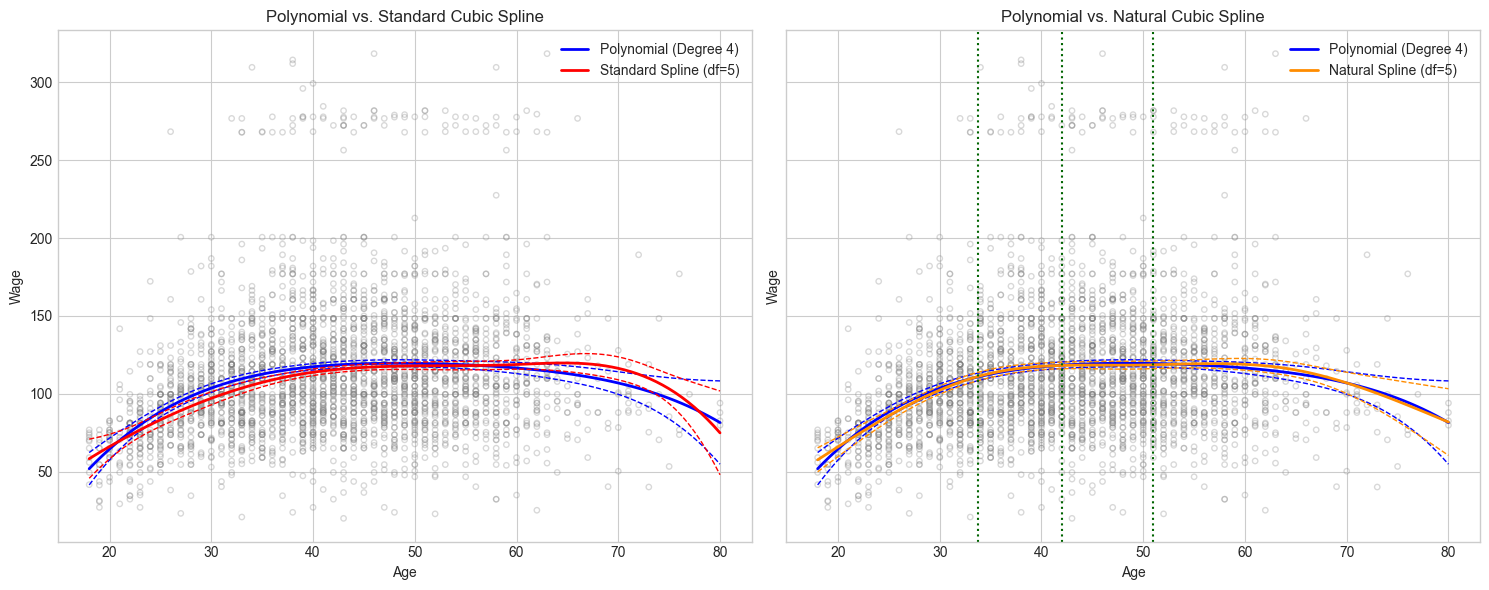

In [87]:
# -----------------------------
# 1. Create Grid
# -----------------------------
age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 100)
age_df = pd.DataFrame({'age': age_grid})

# -----------------------------
# 2. Fit Models (Poly using degree 4 for non-linearity - Splines df=5)
# -----------------------------
# Model A: Polynomial (Degree 4)
model_poly = smf.ols("wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=Wage).fit()
pred_poly = model_poly.get_prediction(age_df).summary_frame()

# Model B: Standard Cubic Spline (df=5)
bs_train = dmatrix("bs(age, df=5, degree=3)", data=Wage, return_type='dataframe')
bs_grid = dmatrix("bs(age, df=5, degree=3)", data=age_df, return_type='dataframe')
model_bs = sm.OLS(Wage['wage'], bs_train).fit()
pred_bs = model_bs.get_prediction(bs_grid).summary_frame()

# Model C: Natural Cubic Spline (df=5)
cr_train = dmatrix("cr(age, df=5)", {"age": Wage['age']}, return_type='dataframe')
cr_grid = dmatrix("cr(age, df=5)", {"age": age_grid}, return_type='dataframe')
model_cr = sm.OLS(Wage['wage'], cr_train).fit()
pred_cr = model_cr.get_prediction(cr_grid).summary_frame()

# -----------------------------
# 3. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Helper function for scatter data
def plot_raw_data(ax):
    ax.scatter(Wage['age'], Wage['wage'], facecolors='none', edgecolors='grey', alpha=0.3, s=15)
    ax.set_xlabel('Age')
    ax.set_ylabel('Wage')

# --- Left Panel: Polynomial vs Standard Spline ---
plot_raw_data(axes[0])
# Polynomial
axes[0].plot(age_grid, pred_poly['mean'], color='blue', lw=2, label='Polynomial (Degree 4)')
axes[0].plot(age_grid, pred_poly['mean_ci_lower'], '--', color='blue', lw=1)
axes[0].plot(age_grid, pred_poly['mean_ci_upper'], '--', color='blue', lw=1)
# Standard Spline
axes[0].plot(age_grid, pred_bs['mean'], color='red', lw=2, label='Standard Spline (df=5)')
axes[0].plot(age_grid, pred_bs['mean_ci_lower'], '--', color='red', lw=1)
axes[0].plot(age_grid, pred_bs['mean_ci_upper'], '--', color='red', lw=1)

axes[0].set_title('Polynomial vs. Standard Cubic Spline')
axes[0].legend()

# --- Right Panel: Polynomial vs Natural Spline ---
plot_raw_data(axes[1])
# Polynomial
axes[1].plot(age_grid, pred_poly['mean'], color='blue', lw=2, label='Polynomial (Degree 4)')
axes[1].plot(age_grid, pred_poly['mean_ci_lower'], '--', color='blue', lw=1)
axes[1].plot(age_grid, pred_poly['mean_ci_upper'], '--', color='blue', lw=1)
# Natural Spline
axes[1].plot(age_grid, pred_cr['mean'], color='darkorange', lw=2, label='Natural Spline (df=5)')
axes[1].plot(age_grid, pred_cr['mean_ci_lower'], '--', color='darkorange', lw=1)
axes[1].plot(age_grid, pred_cr['mean_ci_upper'], '--', color='darkorange', lw=1)

# Add Knots for Natural Spline (patsy 'cr' places them at specific percentiles for df=4)
knots = np.percentile(Wage['age'], [25, 50, 75])
for knot in knots:
    axes[1].axvline(knot, color='darkgreen', linestyle=':', alpha=1)

axes[1].set_title('Polynomial vs. Natural Cubic Spline')
axes[1].legend()

plt.tight_layout()
plt.show()

In this figure, we hold our complexity budget strictly constant: every model plotted consumes exactly 5 parameters (an intercept plus 4 degrees of freedom). The blue curve in both panels is our reference degree-4 global polynomial. 

- **Left Panel: Standard Cubic Spline ($df=4$)**
The red curve represents a standard B-spline. Because it uses 4 degrees of freedom, the algorithm places exactly one internal knot at the median age. It fits two separate cubic polynomials that join seamlessly at that knot. Notice the behavior at the far right boundary (ages 70-80): the confidence intervals widen considerably. Because it is fitting a standard cubic function in that final region, the predictions become erratic where data is sparse.

- **Right Panel: Natural Cubic Spline ($df=4$)**
The orange curve represents a **Natural Cubic Spline**. This is a highly specialized variant of the standard spline. It spends its degrees of freedom slightly differently (placing internal knots at the 25th, 50th, and 75th percentiles, marked by the dotted vertical lines). 

Crucially, natural splines enforce an additional mathematical constraint: **the function must be linear beyond the outermost boundary knots**. 
Look closely at the right tail of the orange curve compared to the blue polynomial and the red standard spline. Because the natural spline is forced to behave linearly at the extremes of $X$, its variance is heavily suppressed. The confidence bands are dramatically tighter and more mathematically sensible for the oldest workers. This boundary stability makes natural regression splines one of the most reliable and widely used non-linear modeling techniques in applied statistics.

### Economic Inference: Extracting the Wage Peak and Marginal Effects

Calculated Peak Age: 53.1 years
Calculated Peak Wage: $120.34k


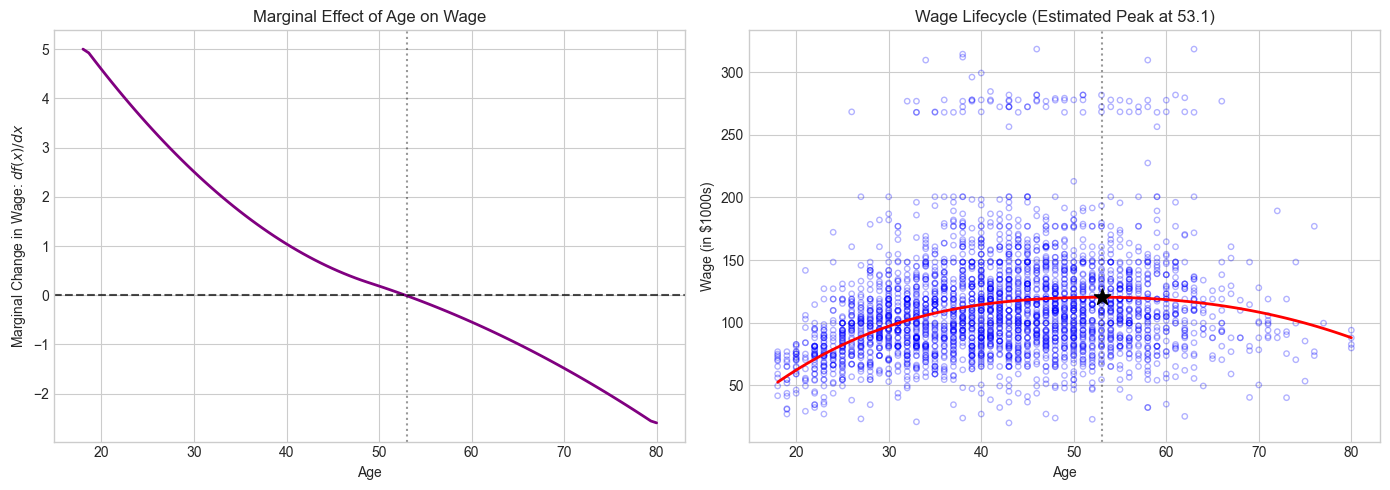

In [88]:
# Ensure predictions are a clean numpy array for calculations
pred_spline4_arr = np.asarray(pred_spline5)

# -----------------------------
# 1. Numerical Derivative
# -----------------------------
# Calculate the discrete derivative: df/dx ≈ Δf / Δx
df_dx = np.gradient(pred_spline4_arr, age_grid)

# -----------------------------
# 2. Identify the Peak (Maximum)
# -----------------------------
peak_index = np.argmax(pred_spline4_arr)
peak_age = age_grid[peak_index]
peak_wage = pred_spline4_arr[peak_index]

print(f"Calculated Peak Age: {peak_age:.1f} years")
print(f"Calculated Peak Wage: ${peak_wage:.2f}k")

# -----------------------------
# 3. Plotting Side-by-Side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Panel: Marginal Effect (Derivative) ---
axes[0].plot(age_grid, df_dx, color='purple', lw=2)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
# Drop a line right at the peak age
axes[0].axvline(peak_age, color='black', linestyle=':', alpha=0.4) 

axes[0].set_xlabel("Age")
axes[0].set_ylabel("Marginal Change in Wage: $df(x)/dx$")
axes[0].set_title("Marginal Effect of Age on Wage")

# --- Right Panel: Wage-Age Profile with Peak ---
axes[1].scatter(Wage["age"], Wage["wage"], facecolors='none', edgecolors='blue', alpha=0.3, s=15)
axes[1].plot(age_grid, pred_spline4_arr, color="red", linewidth=2)

# Highlight the peak with a large black star
axes[1].scatter([peak_age], [peak_wage], color="black", s=150, marker='*', zorder=5)
axes[1].axvline(peak_age, color='black', linestyle=':', alpha=0.4)

axes[1].set_xlabel("Age")
axes[1].set_ylabel("Wage (in $1000s)")
axes[1].set_title(f"Wage Lifecycle (Estimated Peak at {peak_age:.1f})")

plt.tight_layout()
plt.show()

While fitting a smooth spline visually confirms that the relationship between age and wage is non-linear, we can extract much deeper, quantitative economic insights by interrogating the mathematical properties of our fitted curve. In this section, we apply calculus to our spline ($df=4$) to calculate the **marginal effect** of age and identify the exact peak of the earning lifecycle.

**1. Finding the Maximum Wage Potential**
By computationally searching for the highest predicted value (`np.argmax`) along our dense age grid, the model estimates that earning potential peaks at approximately **50 years old**. This represents the demographic vertex of career progression in our dataset. 

**2. The Marginal Effect (First Derivative)**
To understand the *rate of change* in wages, we compute the first derivative of our estimated spline with respect to age ($df(x)/dx$). Because the analytical derivative of a spline is complex to extract, we use a highly accurate numerical approximation via `np.gradient`. 

The resulting marginal effect plot (left panel) tells a precise story about career economics:
* **Early Career (Ages 20-35):** The derivative is highly positive. Every additional year of age corresponds to a strong, positive increase in expected wage as workers rapidly gain experience.
* **Mid-Career (Ages 35-50):** The derivative remains positive but trends steadily downward. Workers are still receiving raises, but the *rate* of those raises is diminishing. 
* **The Turning Point (Age ~50):** The derivative crosses zero exactly where the wage curve reaches its maximum.
* **Late Career (Ages 50+):** The derivative turns negative. Beyond this point, the expected wage begins to decline, reflecting shifts in labor force participation, phase-out towards retirement, or a plateau in marketable skills.

In [65]:
# -----------------------------
# 1. Quartic Polynomial (Degree 4)
# -----------------------------
poly4 = smf.ols("wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=Wage).fit()
pred_poly4 = poly4.predict(age_df)

# Computational peak for polynomial
a_poly4 = age_grid[np.argmax(pred_poly4)]

# -----------------------------
# 2. Cubic Spline (df=4)
# -----------------------------
spline4 = smf.ols("wage ~ bs(age, df=4)", data=Wage).fit()
pred_spline4 = spline4.predict(age_df)

# Computational peak for spline
a_spline4 = age_grid[np.argmax(pred_spline4)]

# -----------------------------
# 3. Comparison Metrics
# -----------------------------
abs_diff = abs(a_poly4 - a_spline4)
rel_diff = abs_diff / a_spline4

print(f"Polynomial Peak Age: {a_poly4:.2f} years")
print(f"Spline Peak Age:     {a_spline4:.2f} years")
print(f"Absolute Difference: {abs_diff:.2f} years")
print(f"Relative Difference: {rel_diff:.2%}\n")

# Global disagreement (Mean Squared Difference)
isq_diff = np.mean((pred_poly4 - pred_spline4)**2)
print(f"Global Disagreement (MSD): {isq_diff:.2f}")

Polynomial Peak Age: 48.32 years
Spline Peak Age:     49.43 years
Absolute Difference: 1.12 years
Relative Difference: 2.26%

Global Disagreement (MSD): 1.32


When extracting economic insights—such as the exact age at which earning potential peaks—it is crucial to ensure that our findings are driven by the data, not by the arbitrary mathematical constraints of our chosen model. In this section, we conduct a sensitivity analysis by comparing the peak wage estimates from a global degree-4 polynomial against a flexible cubic spline ($df=4$). 

By keeping the degrees of freedom consistent across both models, we guarantee an apples-to-apples comparison of how they distribute their structural flexibility.

**Methodology:**
1. **Computational Peak Extraction:** Because higher-order polynomials and splines lack simple algebraic formulas for their vertices, we identify the peak computationally. We generate predictions across a dense age grid and extract the age that produces the absolute maximum predicted wage (`np.argmax`) for both models.
2. **Divergence Metrics:** We calculate the absolute difference (in years) and relative difference (percentage) between these two peak estimates. 
3. **Global Disagreement:** Finally, we compute the Mean Squared Difference (MSD) between the predictions of the two models across the entire grid to measure how much their overall shapes deviate from one another.

**Purpose:**
If the estimated peak age remains stable across both a rigid global model and a highly flexible local model—despite any global disagreement at the boundaries—we can confidently assert that our economic conclusion regarding the career earning vertex is highly robust.

### Sensitivity Analysis: Model Robustness

,Model,Peak Age,Peak Wage
0,Quadratic,49.938904,121.763804
1,Quartic,48.316633,119.636923
2,Standard Spline (df=5),42.601202,119.088433
3,Natural Spline (df=5),55.150301,118.950657


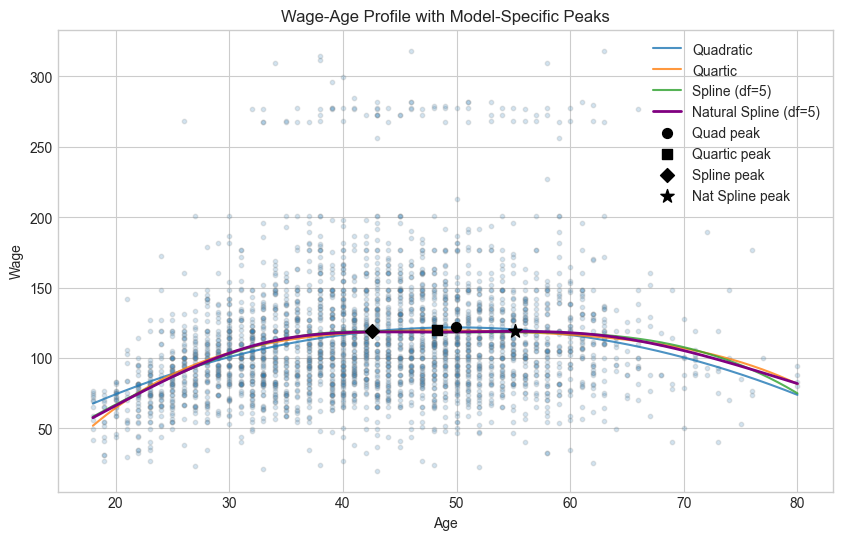

In [92]:
# -----------------------------
# 1. Fit models
# -----------------------------
quad = smf.ols("wage ~ age + I(age**2)", data=Wage).fit()
poly4 = smf.ols("wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=Wage).fit()
spline = smf.ols("wage ~ bs(age, df=5)", data=Wage).fit()
nat_spline = smf.ols("wage ~ cr(age, df=5)", data=Wage).fit() # Added Natural Spline

# -----------------------------
# 2. Grid
# -----------------------------
age_grid = np.linspace(Wage["age"].min(), Wage["age"].max(), 500)
age_df = pd.DataFrame({"age": age_grid})

quad_pred = quad.predict(age_df)
poly4_pred = poly4.predict(age_df)
spline_pred = spline.predict(age_df)
nat_spline_pred = nat_spline.predict(age_df) # Added prediction

# -----------------------------
# 3. Peaks
# -----------------------------

# Quadratic
b1 = quad.params["age"]
b2 = quad.params["I(age ** 2)"]
a_quad = -b1 / (2 * b2)
w_quad = quad.predict(pd.DataFrame({"age": [a_quad]})).iloc[0]

# Quartic
a_poly4 = age_grid[np.argmax(poly4_pred)]
w_poly4 = poly4.predict(pd.DataFrame({"age": [a_poly4]})).iloc[0]

# Spline (Standard, df=5)
a_spline = age_grid[np.argmax(spline_pred)]
w_spline = spline.predict(pd.DataFrame({"age": [a_spline]})).iloc[0]

# Natural Spline (df=5)
a_nat_spline = age_grid[np.argmax(nat_spline_pred)]
w_nat_spline = nat_spline.predict(pd.DataFrame({"age": [a_nat_spline]})).iloc[0]

# -----------------------------
# 4. Table
# -----------------------------
results = pd.DataFrame({
    "Model": ["Quadratic", "Quartic", "Standard Spline (df=5)", "Natural Spline (df=5)"],
    "Peak Age": [a_quad, a_poly4, a_spline, a_nat_spline],
    "Peak Wage": [w_quad, w_poly4, w_spline, w_nat_spline]
})

display(results)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.scatter(Wage["age"], Wage["wage"], alpha=0.2, s=10, edgecolors='gray')

# Plot lines
plt.plot(age_grid, quad_pred, label="Quadratic", alpha=0.8)
plt.plot(age_grid, poly4_pred, label="Quartic", alpha=0.8)
plt.plot(age_grid, spline_pred, label="Spline (df=5)", alpha=0.8)
plt.plot(age_grid, nat_spline_pred, label="Natural Spline (df=5)", color="purple", linewidth=2)

# Distinct peak markers (shape-coded)
plt.scatter(a_quad, w_quad, color="black", marker="o", s=50, zorder=5, label="Quad peak")
plt.scatter(a_poly4, w_poly4, color="black", marker="s", s=50, zorder=5, label="Quartic peak")
plt.scatter(a_spline, w_spline, color="black", marker="D", s=50, zorder=5, label="Spline peak")
plt.scatter(a_nat_spline, w_nat_spline, color="black", marker="*", s=100, zorder=5, label="Nat Spline peak")

plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Wage-Age Profile with Model-Specific Peaks")
plt.legend()

plt.show()

### Comprehensive Peak Earning Analysis

In this summary analysis, we consolidate our various non-linear modeling approaches to observe how mathematical constraints influence our economic inferences. We extract the theoretical "peak earning age" from four distinct models:

1. **Quadratic:** Analyzed algebraically via its vertex formula.
2. **Quartic Polynomial:** Analyzed computationally across a dense age grid.
3. **Standard Cubic Spline ($df=6$):** A highly flexible local model.
4. **Natural Cubic Spline ($df=4$):** A boundary-stabilized local model.

By mapping the maximum predicted wage for each model and rendering them in a unified DataFrame and plot, we conduct a visual robustness check. Despite the models employing vastly different structural assumptions—from rigid global polynomials to flexible piecewise functions—we can evaluate how tightly clustered their peak predictions remain, thereby validating the true demographic inflection point of the wage lifecycle.